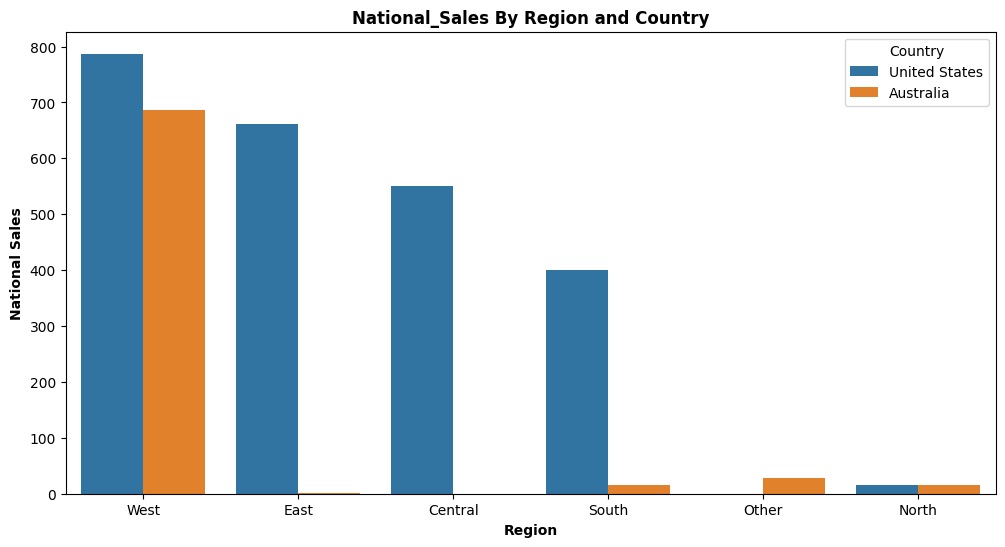

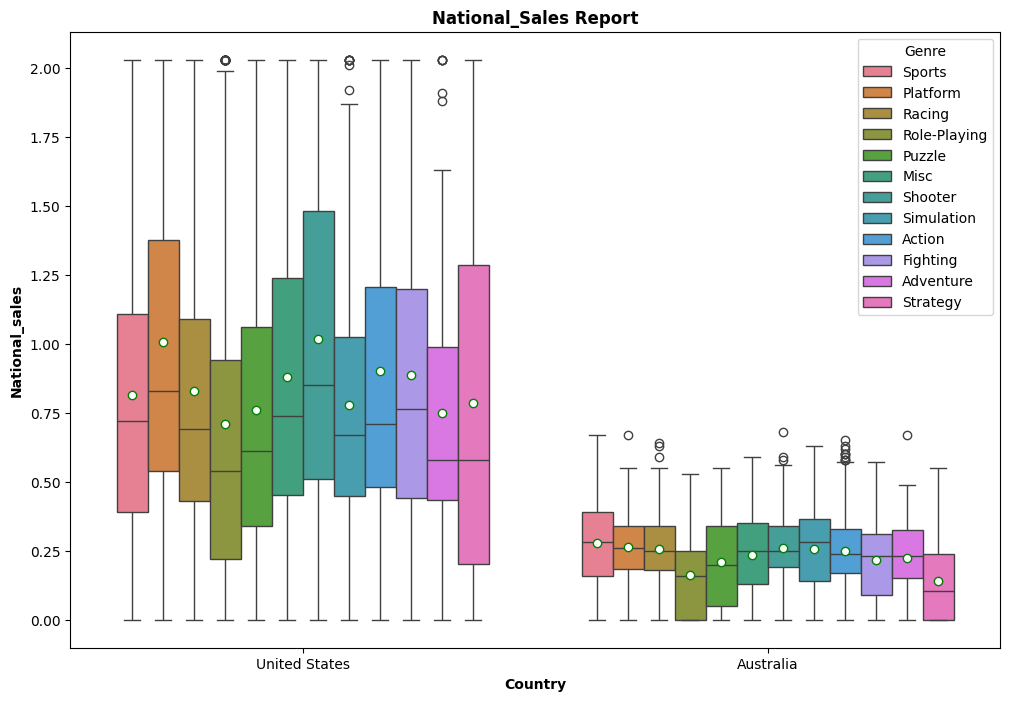

,Country,National Sales,Global Sales
0,Australia,747.62,1468.25
1,United States,2415.88,6315.68


In [80]:



import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Load CSV
df = pd.read_csv("D:/python/project/VideoGamesSales.csv")

# Data cleaning
df = df.drop_duplicates()
df['Publisher'] = df['Publisher'].fillna("Shayan")
df['Region'] = df['Region'].fillna("North")
df['Country'] = df['Country'].replace({'USA': 'United States'})
# # df = df[df['Country'] == 'United States']
# df.shape[0]

# Rename columns
df = df.rename(columns={
    'NA_Sales': 'National Sales',
    'Global_Sales': 'Global Sales',
    'NA_Profit': 'National Profit',
    'Global_Profit': 'Global Profit'
})

# Convert sales column to numeric
df['National Sales'] = pd.to_numeric(df['National Sales'], errors='coerce')

median_val = df['National Sales'].median()
df['National Sales'] = df['National Sales'].fillna(median_val)


# Apply capping (95th percentile)
Sales_cap = df['National Sales'].quantile(0.95)
df['National Sales'] = np.where(df['National Sales'] > Sales_cap, Sales_cap, df['National Sales'])

# Create a bar chart
National_sales = df.groupby(['Region','Country'])['National Sales'].sum().reset_index().sort_values(by='National Sales', ascending=False)
plt.figure(figsize=(12,6))

sns.barplot(data=National_sales,x='Region',y='National Sales',hue='Country')
plt.title("National_Sales By Region and Country"  ,fontweight='bold')
plt.xlabel("Region" ,fontweight='bold')
plt.ylabel("National Sales" ,fontweight='bold')
plt.show()

# Create a boxplot
plt.figure(figsize=(12,8))
sns.boxplot(x='Country',y='National Sales' ,showmeans=True,data=df ,hue='Genre',meanprops={"marker":"o", "markerfacecolor":"white",'markeredgecolor':'green','markersize':'6'})
plt.title("National_Sales Report"  ,fontweight='bold')
plt.xlabel("Country" ,fontweight='bold')
plt.ylabel("National_sales"  ,fontweight='bold')
plt.show()


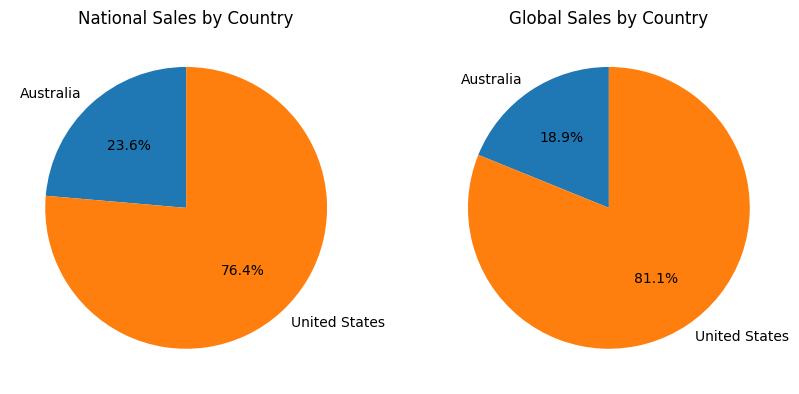

In [92]:
# Create a Pie chart
Sales = df.groupby(['Country'])[['National Sales','Global Sales']].sum().reset_index()
Country=Sales['Country']
National_sales=Sales['National Sales']
Global_sales=Sales['Global Sales']
fig ,ax=plt.subplots(1,2,figsize=(10,7))
ax[0].pie(National_sales,labels=Country,autopct='%1.1f%%',startangle=90)
ax[0].set_title("National Sales by Country")

ax[1].pie(Global_sales,labels=Country,autopct='%1.1f%%',startangle=90)
ax[1].set_title("Global Sales by Country")
plt.show()

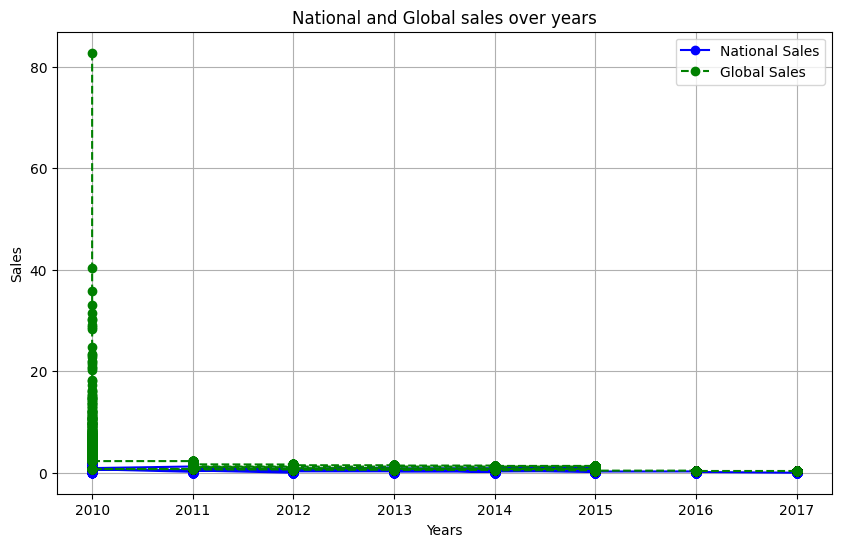

In [96]:
# Create a line chart
plt.figure(figsize=(10,6))
plt.plot(df['Year'],df['National Sales'],color='b',linestyle='-',marker='o',label='National Sales')

plt.plot(df['Year'],df['Global Sales'],color='g',linestyle='--',marker='o',label='Global Sales')

plt.xlabel("Years")
plt.ylabel("Sales")
plt.title('National and Global sales over years')
plt.grid(True)
plt.legend()
plt.show()